In [13]:
import gc
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = Path(Path.cwd()).parent / "Data"
plot_dir = Path(Path.cwd()) / 'Plots'

In [14]:
# Shapefiles
kreise = gpd.read_file(Path(data_dir / "Shapefiles-2022" / "Germany" / "COUNTIES" / "VG250_KRS_clean_final.shp"))

# Join county_id 16056 into county_id 16063
from shapely.ops import unary_union
kreise.loc[kreise["RS"].isin(["16056", "16063"]), "geometry"] = unary_union(
    kreise.loc[kreise["RS"].isin(["16056", "16063"]), "geometry"]
)
kreise = gpd.GeoDataFrame(kreise[~kreise["RS"].isin(["16056"])].copy())


In [15]:
# Load the data
data_wk, meta_wk = pyreadstat.read_dta(Path(data_dir / "RWI-GEO-RED-2022" / "cross_section" / "CampusFile_WK_2022.dta"))
data_hk, meta_hk = pyreadstat.read_dta(Path(data_dir / "RWI-GEO-RED-2022" / "cross_section" / "CampusFile_HK_2022.dta"))

data_wm, meta_wm = pyreadstat.read_dta(Path(data_dir / "RWI-GEO-RED-2022" / "cross_section" / "CampusFile_WM_2022.dta"))

In [16]:
# Price/rent in logs

data_wk["log_price_sqm"] = np.log(data_wk["price_sqm"])
data_wk["type"] = "WK"
data_hk["log_price_sqm"] = np.log(data_hk["price_sqm"])
data_hk["type"] = "HK"

data_wm["log_rent_sqm"] = np.log(data_wm["rent_sqm"])

# Concatenate the dataframes wk and hk
data_k = pd.concat([data_wk, data_hk], ignore_index=True)
data_k["kid2019"] = data_k["kid2019"].astype(str).str.zfill(5)

del data_wk, data_hk
gc.collect()

6087

In [17]:
mean_log_price_sqm = data_k["log_price_sqm"].groupby(data_k['kid2019']).mean()

# Which indexes of mean_log_price_sqm are not in kreise['county_id']?
missing_kids = mean_log_price_sqm.index[~mean_log_price_sqm.index.isin(kreise['county_id'])]
print(missing_kids)

# KID2019 '03152', '03156' are actually 03159 -> Landkreis Göttingen

# Replace '03152' and '03156' with '03159' in all data
data_k["kid2019"] = data_k["kid2019"].replace({"03152": "03159", "03156": "03159"})
data_wm["kid2019"] = data_wm["kid2019"].replace({"03152": "03159", "03156": "03159"})

# Replace 16056 by 16063 -> Wartburgkreis.
data_k["kid2019"] = data_k["kid2019"].replace({"16056": "16063"})
data_wm["kid2019"] = data_wm["kid2019"].replace({"16056": "16063"})

Index(['-0009', '03152', '03156', '16056'], dtype='object', name='kid2019')


In [18]:
mean_log_price_sqm = data_k["log_price_sqm"].groupby(data_k['kid2019']).mean()

# Join the geometries to the data
mean_log_price_sqm = kreise.merge(mean_log_price_sqm, left_on="county_id", right_index=True)


In [19]:
# Set up for plotting
# Params for clean and minimalistic plots
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (6*2, 2*4.5),
    'font.size': 14.0,
    'font.family': 'serif',
    'font.serif': 'Palatino',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'large',
    'legend.fontsize': 'medium',
    # dpi for high-res output
    'figure.dpi': 100,
    'savefig.dpi': 300,
    # Tight layout by default
    'figure.autolayout': True,
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{siunitx}[=v2]",
})

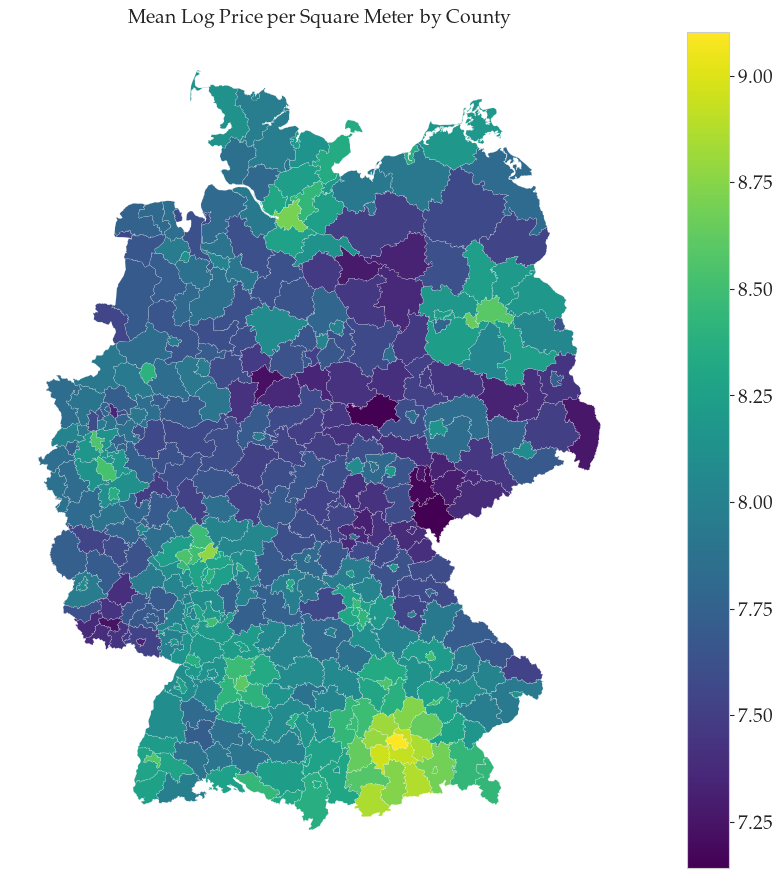

In [20]:
# Plot the means of log price per sqm
fig, ax = plt.subplots()
mean_log_price_sqm.plot(column="log_price_sqm", cmap="viridis", linewidth=0.1, ax=ax, edgecolor='white', legend=True)
ax.set_title("Mean Log Price per Square Meter by County")
ax.set_axis_off()
plt.savefig(plot_dir / "mean_log_price_sqm.png", bbox_inches='tight')
plt.show()

# Estimation of the model for the properties for sale

The model specification looks as follows:
$$
\ln(p_j) = \alpha + \sum_{i\in \mathcal{V}} \beta_i \cdot i_j + \mu_j
$$
with
$$
\mathcal{V} := \{\text{\texttt{wohnflaeche}}, \,\text{\texttt{zimmeranzahl}}, \,\text{\texttt{baujahr\_bin}}, \,\text{\texttt{ausstattung}}, \,\text{\texttt{objektzustand}},\, \text{\texttt{apartment}}\}
$$
or
$$
\mathcal{V}^* := \mathcal{V} \, \cup \, \{\text{\texttt{balkon}}, \,\text{\texttt{aufzug}}, \,\text{\texttt{parkplatz}}, \,\text{\texttt{keller}}\}
$$


In [21]:
# Helpers
def impute_median(x):
    valid_median = x[x >= 0].median()
    return x.mask(x < 0, valid_median)

In [22]:
# Data cleaning and preparations

# wohnflaeche
print("Number of missing values in wohnflaeche:", sum(data_k['wohnflaeche'] < 0), data_k['wohnflaeche'].isna().sum())

# zimmeranzahl
print("Number of missing values in zimmeranzahl:", sum(data_k['zimmeranzahl'] < 0), data_k['zimmeranzahl'].isna().sum())
# replace by county median
data_k['zimmeranzahl'] = data_k.groupby('kid2019')['zimmeranzahl'].transform(impute_median)
print("After imputation, number of missing values in zimmeranzahl:", sum(data_k['zimmeranzahl'] < 0), data_k['zimmeranzahl'].isna().sum())

# baujahr
print("Number of missing values in baujahr:", sum(data_k['baujahr'] < 0), data_k['baujahr'].isna().sum())
# binning the years into categories
bins = [0, 1900, 1918, 1945, 1960, 1978, 1990, 2000, 2010, np.inf]
labels = [
    "pre_1900", "1900_1918", "1919_1945",
    "1946_1960", "1961_1978", "1979_1990",
    "1991_2000", "2001_2010", "2011_plus"
]

# bin valid years
data_k["baujahr_bin"] = pd.cut(
    data_k["baujahr"],
    bins=bins,
    labels=labels,
    right=True
)

# add unknown category and assign all invalid/missing to it
data_k["baujahr_bin"] = data_k["baujahr_bin"].cat.add_categories("unknown")
data_k.loc[
    data_k["baujahr"].isna() | (data_k["baujahr"] < 1500),
    "baujahr_bin"
] = "unknown"
print("After binning and imputation, number of missing values in baujahr_bin:", data_k['baujahr_bin'].isna().sum())

# ausstattung
print("Number of missing values in ausstattung:", sum(data_k['ausstattung'] < 0), data_k['ausstattung'].isna().sum())
# replace <0 by 0 and create dummy variable for missing
data_k['ausstattung'] = data_k['ausstattung'].mask(data_k['ausstattung'] < 0, 0)
data_k['ausstattung_missing'] = data_k['ausstattung'].isin([0]).astype(int)
print("After imputation, number of missing values in ausstattung:", sum(data_k['ausstattung'] < 0), data_k['ausstattung'].isna().sum())

for val in [2, 3, 4]:  # 1 is reference, excluded
    data_k[f"a_{val}"] = (data_k["ausstattung"] == val).astype(int)

# objektzustand
print("Number of missing values in objektzustand:", sum(data_k['objektzustand'] < 0), data_k['objektzustand'].isna().sum())
# replace <0 and 9 by 0 and create dummy variable for missing
data_k["objektzustand_val"] = data_k["objektzustand"].replace({-7: np.nan, 9: np.nan})
data_k["objektzustand_missing"] = data_k["objektzustand"].isin([-7, 9]).astype(int)
data_k["objektzustand_val"] = data_k["objektzustand_val"].fillna(0)
print("After imputation, number of missing values in objektzustand_val:", sum(data_k['objektzustand_val'] < 0), data_k['objektzustand_val'].isna().sum())

for val in [1, 2, 3, 4, 5, 6, 8, 10]:  # 7 is reference, excluded
    data_k[f"oz_{val}"] = (data_k["objektzustand"] == val).astype(int)

# apartment
data_k["apartment"] = data_k['type'].map({"WK": 1, "HK": 0})

# balkon
print("Number of missing values in balkon:", sum(data_k['balkon'] < 0), data_k['balkon'].isna().sum())
print("Number of missing values in balkon (WK):", sum(data_k.loc[data_k['type'] == "WK", 'balkon'] < 0), data_k.loc[data_k['type'] == "WK", 'balkon'].isna().sum())
print("Number of missing values in balkon (HK):", sum(data_k.loc[data_k['type'] == "HK", 'balkon'] < 0), data_k.loc[data_k['type'] == "HK", 'balkon'].isna().sum())
# replace np.nan by 0, since it will be interacted with apartment variable
data_k['balkon'] = data_k['balkon'].fillna(0)

# Aufzug
print("Number of missing values in aufzug:", sum(data_k['aufzug'] < 0), data_k['aufzug'].isna().sum())
print("Number of missing values in aufzug (WK):", sum(data_k.loc[data_k['type'] == "WK", 'aufzug'] < 0), data_k.loc[data_k['type'] == "WK", 'aufzug'].isna().sum())
print("Number of missing values in aufzug (HK):", sum(data_k.loc[data_k['type'] == "HK", 'aufzug'] < 0), data_k.loc[data_k['type'] == "HK", 'aufzug'].isna().sum())
# replace np.nan by 0, since it will be interacted with apartment variable
data_k['aufzug'] = data_k['aufzug'].fillna(0)

# Keller
print("Number of missing values in keller:", sum(data_k['keller'] < 0), data_k['keller'].isna().sum())
print("Number of missing values in keller (WK):", sum(data_k.loc[data_k['type'] == "WK", 'keller'] < 0), data_k.loc[data_k['type'] == "WK", 'keller'].isna().sum())
print("Number of missing values in keller (HK):", sum(data_k.loc[data_k['type'] == "HK", 'keller'] < 0), data_k.loc[data_k['type'] == "HK", 'keller'].isna().sum())
# no na

# Parkplatz
print("Number of missing values in parkplatz:", sum(data_k['parkplatz'] < 0), data_k['parkplatz'].isna().sum())
print("Number of missing values in parkplatz (WK):", sum(data_k.loc[data_k['type'] == "WK", 'parkplatz'] < 0), data_k.loc[data_k['type'] == "WK", 'parkplatz'].isna().sum())
print("Number of missing values in parkplatz (HK):", sum(data_k.loc[data_k['type'] == "HK", 'parkplatz'] < 0), data_k.loc[data_k['type'] == "HK", 'parkplatz'].isna().sum())
# replace <0 by 0 and create dummy variable for missing
data_k['parkplatz_missing'] = (data_k['parkplatz'] < 0).astype(int)
data_k['parkplatz'] = data_k['parkplatz'].mask(data_k['parkplatz'] < 0, 0)

print("After imputation, number of missing values in parkplatz:", sum(data_k['parkplatz'] < 0), data_k['parkplatz'].isna().sum())

Number of missing values in wohnflaeche: 0 0
Number of missing values in zimmeranzahl: 308 0
After imputation, number of missing values in zimmeranzahl: 0 0
Number of missing values in baujahr: 0 74954
After binning and imputation, number of missing values in baujahr_bin: 0
Number of missing values in ausstattung: 179803 0
After imputation, number of missing values in ausstattung: 0 0
Number of missing values in objektzustand: 165684 0
After imputation, number of missing values in objektzustand_val: 0 0
Number of missing values in balkon: 0 259347
Number of missing values in balkon (WK): 0 0
Number of missing values in balkon (HK): 0 259347
Number of missing values in aufzug: 0 259347
Number of missing values in aufzug (WK): 0 0
Number of missing values in aufzug (HK): 0 259347
Number of missing values in keller: 0 0
Number of missing values in keller (WK): 0 0
Number of missing values in keller (HK): 0 0
Number of missing values in parkplatz: 185925 0
Number of missing values in parkp

In [ ]:
import statsmodels.formula.api as smf
import gc

# --- ensure kid2019 is zero-padded string ---
data_k["kid2019"] = data_k["kid2019"].astype(str).str.zfill(5)

# --- drop invalid county codes ---
data_k = data_k[~(data_k['kid2019'] == '-0009')]

# --- formula ---
formula = (
    "log_price_sqm ~ "
    "C(baujahr_bin, Treatment('1991_2000')) + "
    "zimmeranzahl + "
    "wohnflaeche + "
    "a_2 + a_3 + a_4 + ausstattung_missing + "
    "oz_1 + oz_2 + oz_3 + oz_4 + oz_5 + oz_6 + oz_8 + oz_10 + objektzustand_missing + "
    "apartment:balkon + apartment:aufzug + apartment:keller + "
    "parkplatz + parkplatz_missing + "
    "apartment + "
    "C(kid2019, Treatment('05566'))"
)

model = smf.ols(formula, data=data_k).fit()
print(model.summary())

# --- extract county fixed effects ---
params = model.params

# get all county params robustly
county_params_raw = params[
    params.index.str.contains("kid2019") &
    params.index.str.contains(r"\[T\.", regex=True)
].copy()

# debug: inspect actual parameter names
print("Sample parameter names:")
print(county_params_raw.head(5).index.tolist())

# extract kid2019 value from inside [T. ... ]
county_fe = county_params_raw.copy()
county_fe.index = county_fe.index.str.extract(r"\[T\.(.+)\]")[0]

# add reference county Hamburg with FE = 0
county_fe["05566"] = 0.0

print(f"N counties extracted: {len(county_fe)}")
assert len(county_fe) > 100, "Too few counties — check kid2019 dtype and Treatment reference"

# sort and name
county_fe = county_fe.sort_index()
county_fe.name = "purchase_price_index"

# demean
county_fe_demeaned = county_fe

print(f"Mean of demeaned FEs: {county_fe_demeaned.mean():.6f}")  # should be ~0
print(f"N counties in index: {len(county_fe_demeaned)}")

gc.collect()

                            OLS Regression Results                            
Dep. Variable:          log_price_sqm   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     1762.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:36:00   Log-Likelihood:            -1.1776e+05
No. Observations:              409087   AIC:                         2.364e+05
Df Residuals:                  408657   BIC:                         2.411e+05
Df Model:                         429                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

10137

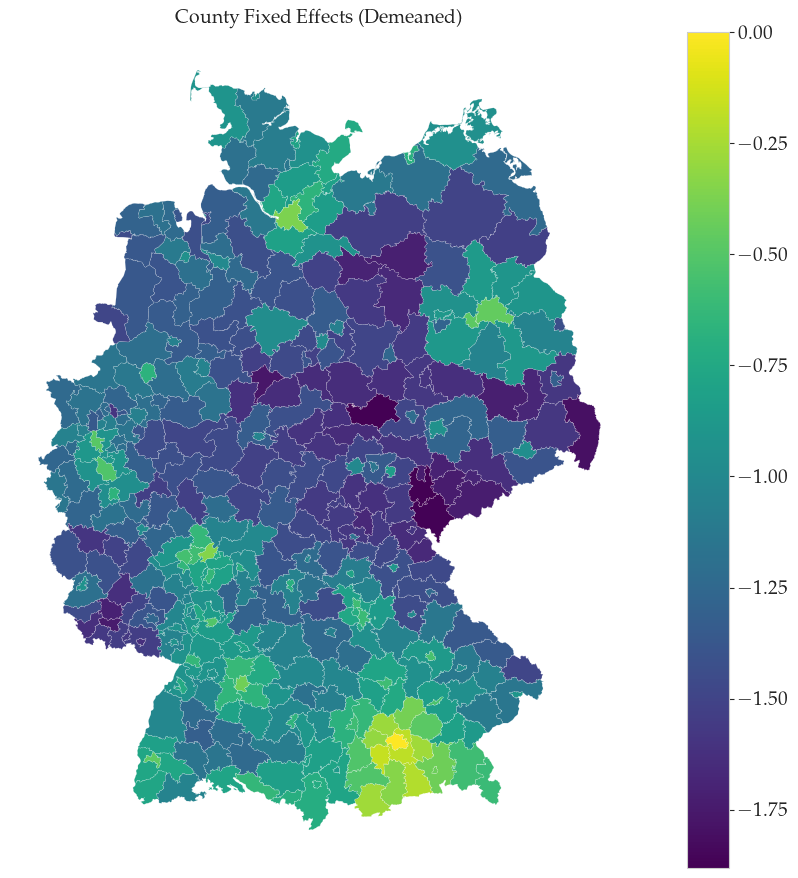

In [24]:
# Change the index of county_fe_demeaned to string
county_fe_demeaned.index = county_fe_demeaned.index.astype(str).str.zfill(5)
# Plot the data
# Join the geometries to the data
county_fe_gdf = kreise.merge(county_fe_demeaned, left_on="county_id", right_index=True)
fig, ax = plt.subplots()
county_fe_gdf.plot(column="purchase_price_index", cmap="viridis", linewidth=0.1, ax=ax, edgecolor='white', legend=True)
ax.set_title("County Fixed Effects (Demeaned)")
ax.set_axis_off()
plt.savefig(plot_dir / "county_fixed_effects.png", bbox_inches='tight')
plt.show()

# Save to csv
county_fe_demeaned.to_csv("county_fixed_effects_demeaned.csv", header=True)

In [ ]:
# Model setup
# Define the formula for the regression model
import statsmodels.formula.api as smf

data_k = data_k[~(data_k['kid2019'] == '-0009')]

formula = (
    "log_price_sqm ~ "
    "C(baujahr_bin, Treatment('1991_2000')) + "
    "zimmeranzahl + "
    "wohnflaeche + "
    "a_2 + a_3 + a_4 + ausstattung_missing + "
    "oz_1 + oz_2 + oz_3 + oz_4 + oz_5 + oz_6 + oz_8 + oz_10 + objektzustand_missing + "
    "apartment:balkon + apartment:aufzug + apartment:keller + "
    "parkplatz + parkplatz_missing + "
    "apartment + "
    "C(kid2019, Treatment('02000'))"
)

'''
formula = (
    "log_price_sqm ~ "
    "C(baujahr_bin, Treatment('1991_2000')) + "
    "zimmeranzahl + "
    "wohnflaeche + "
    "C(kid2019, Treatment('02000'))"
)
'''

model = smf.ols(formula, data=data_k).fit()
print(model.summary())

'''
# --- extract county fixed effects ---
params = model.params
county_fe = params[params.index.str.startswith("C(kid2019)")].copy()

# extract as string, keep consistent
county_fe.index = (
    county_fe.index
    .str.extract(r"C\(kid2019\)\[T\.(.+)\]")[0]
)

# add reference county as string too
reference_county = str(data_k["kid2019"].value_counts().idxmax())
county_fe[reference_county] = 0.0
county_fe.index = county_fe.index.astype(int)
county_fe = county_fe.sort_index()
county_fe.name = "purchase_price_index"

county_fe_demeaned = county_fe - county_fe.mean()
'''

# --- extract county fixed effects ---
params = model.params
county_fe = params[params.index.str.startswith("C(kid2019)")].copy()

# extract kid2019 values from parameter names
county_fe.index = (
    county_fe.index
    .str.extract(r"C\(kid2019,\s*Treatment\('02000'\)\)\[T\.(.+)\]")[0]
)

# add reference county with FE = 0
county_fe["02000"] = 0.0

# convert to int, sort, name
county_fe.index = county_fe.index.astype(int)
county_fe = county_fe.sort_index()
county_fe.name = "purchase_price_index"

county_fe_demeaned = county_fe - county_fe.mean()

print(f"Mean of demeaned FEs: {county_fe_demeaned.mean():.6f}")  # should be ~0
print(f"N counties: {len(county_fe_demeaned)}")


gc.collect()

                            OLS Regression Results                            
Dep. Variable:          log_price_sqm   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     1762.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:21:38   Log-Likelihood:            -1.1776e+05
No. Observations:              409087   AIC:                         2.364e+05
Df Residuals:                  408657   BIC:                         2.411e+05
Df Model:                         429                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

10265